# Cardiovascular Disease Classification

**Goal:** Build, compare, tune, and evaluate machine-learning models for predicting cardiovascular disease (`cardio`).

This notebook keeps the original dataset and problem, but reorganizes the workflow from preprocessing → EDA → feature engineering → model training → hyperparameter tuning → final evaluation.

## 1. Imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve
)

RANDOM_STATE = 42

## 2. Load Dataset

In [2]:
df = pd.read_csv("cardio_train.csv", sep=";")
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (70000, 13)


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


## 3. Preprocessing

- Convert `age` from days to years.
- Remove `id` because it is only an identifier.
- Remove impossible blood-pressure records using the same cleaning logic used in the original notebook.

In [4]:
df["age"] = (df["age"] / 365.25).round(1)
df = df.drop(columns=["id"])

print("Missing values:")
print(df.isnull().sum())

print("Duplicate rows:", df.duplicated().sum())

Missing values:
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64
Duplicate rows: 674


In [5]:
df = df[
    (df["ap_hi"] >= 60) &
    (df["ap_hi"] <= 200) &
    (df["ap_lo"] >= 40) &
    (df["ap_lo"] <= 200) &
    (df["ap_hi"] >= df["ap_lo"])
].copy()

print("Shape after cleaning:", df.shape)

Shape after cleaning: (68622, 12)


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,68622.0,53.289639,6.758767,29.6,48.3,53.9,58.4,64.9
gender,68622.0,1.348474,0.476491,1.0,1.0,1.0,2.0,2.0
height,68622.0,164.358792,8.182958,55.0,159.0,165.0,170.0,250.0
weight,68622.0,74.109943,14.325695,11.0,65.0,72.0,82.0,200.0
ap_hi,68622.0,126.603917,16.507518,60.0,120.0,120.0,140.0,200.0
ap_lo,68622.0,81.280479,9.398381,40.0,80.0,80.0,90.0,182.0
cholesterol,68622.0,1.364358,0.678719,1.0,1.0,1.0,1.0,3.0
gluc,68622.0,1.225598,0.571501,1.0,1.0,1.0,1.0,3.0
smoke,68622.0,0.087946,0.283218,0.0,0.0,0.0,0.0,1.0
alco,68622.0,0.053336,0.224704,0.0,0.0,0.0,0.0,1.0


## 4. Exploratory Data Analysis

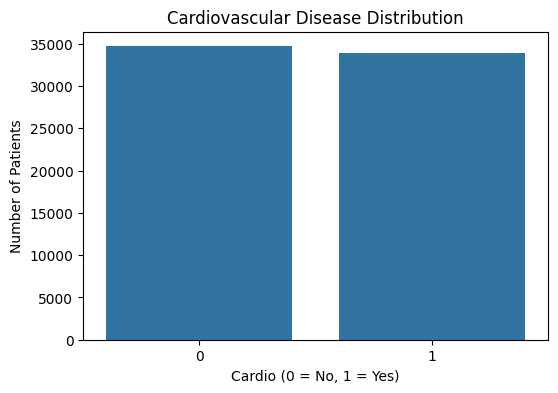

In [7]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="cardio")
plt.title("Cardiovascular Disease Distribution")
plt.xlabel("Cardio (0 = No, 1 = Yes)")
plt.ylabel("Number of Patients")
plt.show()

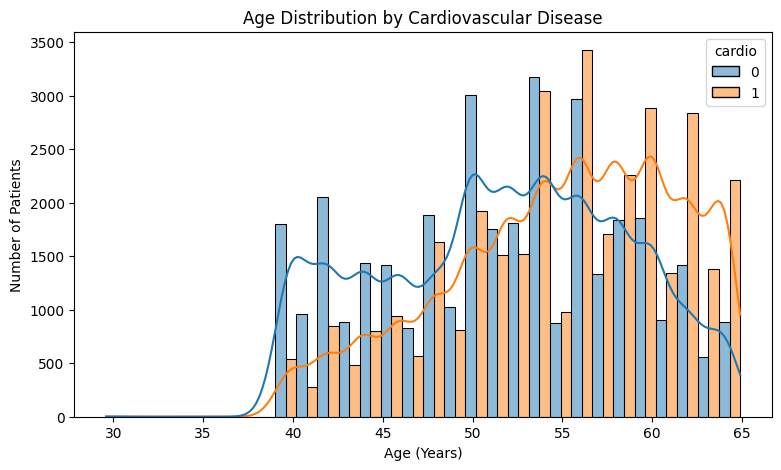

In [8]:
plt.figure(figsize=(9, 5))
sns.histplot(data=df, x="age", hue="cardio", bins=30, kde=True, multiple="dodge")
plt.title("Age Distribution by Cardiovascular Disease")
plt.xlabel("Age (Years)")
plt.ylabel("Number of Patients")
plt.show()

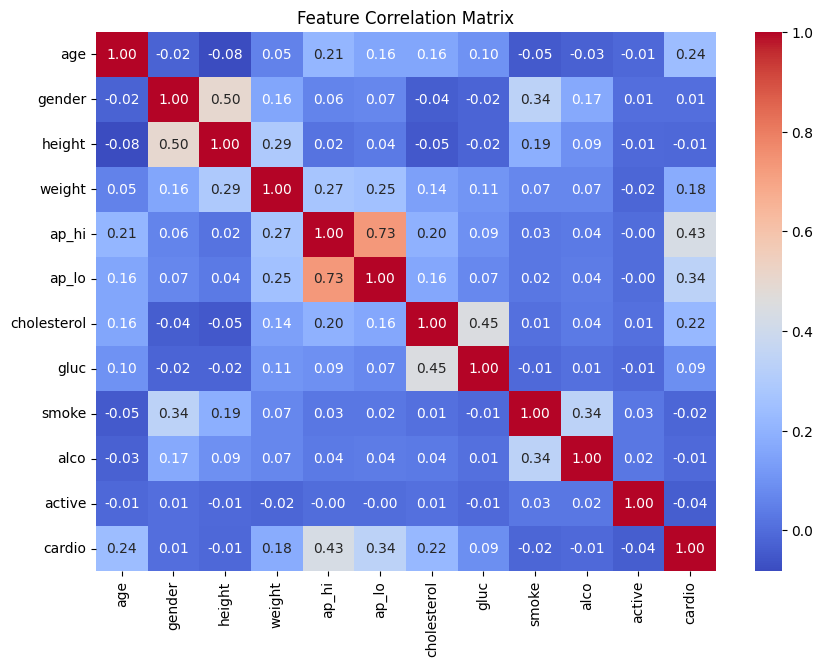

In [9]:
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

## 5. Feature Engineering

Create clinically meaningful numeric features from the existing variables:
- **BMI** from height and weight
- **Pulse Pressure** = systolic − diastolic pressure
- **MAP** = mean arterial pressure
- **Age²** to let linear models capture some non-linear age effects

In [10]:
df["BMI"] = df["weight"] / ((df["height"] / 100) ** 2)
df["pulse_pressure"] = df["ap_hi"] - df["ap_lo"]
df["MAP"] = (df["ap_hi"] + 2 * df["ap_lo"]) / 3
df["age_squared"] = df["age"] ** 2

print(df[["age", "BMI", "pulse_pressure", "MAP", "age_squared"]].head())

    age        BMI  pulse_pressure         MAP  age_squared
0  50.4  21.967120              30   90.000000      2540.16
1  55.4  34.927679              50  106.666667      3069.16
2  51.6  23.507805              60   90.000000      2662.56
3  48.2  28.710479              50  116.666667      2323.24
4  47.8  23.011177              40   73.333333      2284.84


## 6. Prepare Features and Train/Test Split

In [11]:
X = df.drop(columns=["cardio"])
y = df["cardio"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (54897, 15)
X_test : (13725, 15)
y_train: (54897,)
y_test : (13725,)


## 7. Baseline Models

Scaled models use a `Pipeline` so that the scaler is fitted only on the training data.

In [12]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=3000, random_state=RANDOM_STATE))
    ]),

    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=7))
    ]),


    "Decision Tree": DecisionTreeClassifier(
        max_depth=5, min_samples_split=10, min_samples_leaf=5, random_state=RANDOM_STATE
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=10, min_samples_split=5,
        min_samples_leaf=2, random_state=RANDOM_STATE, n_jobs=-1
    )
}

In [13]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob) if y_prob is not None else np.nan
    }

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    metrics = evaluate_model(model, X_test, y_test)
    metrics["Model"] = name
    results.append(metrics)

results = pd.DataFrame(results)[
    ["Model", "Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
].sort_values("Accuracy", ascending=False)

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
3,Random Forest,0.733406,0.752177,0.687343,0.718300,0.797532
2,Decision Tree,0.729545,0.752837,0.674525,0.711532,0.789468
0,Logistic Regression,0.724590,0.748061,0.668042,0.705791,0.789788
1,KNN,0.701348,0.703205,0.685281,0.694127,0.753781


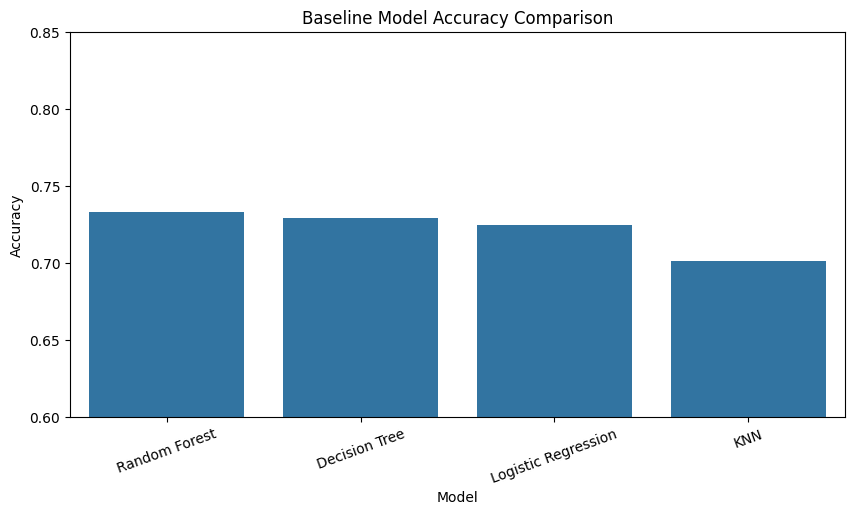

In [14]:
plt.figure(figsize=(10, 5))
sns.barplot(data=results, x="Model", y="Accuracy")
plt.title("Baseline Model Accuracy Comparison")
plt.ylim(0.60, 0.85)
plt.xticks(rotation=20)
plt.show()

## 8. Hyperparameter Tuning

We tune the models rather than assuming a particular parameter setting is best. Grid search uses cross-validation on the training set, then the untouched test set is used only for final evaluation.

### 8.1 Tune Logistic Regression

In [15]:
logistic_grid = GridSearchCV(
    Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=3000, random_state=RANDOM_STATE))
    ]),
    {"model__C": [0.01, 0.1, 0.5, 1, 2, 5, 10]},
    cv=5, scoring="accuracy", n_jobs=-1
)

logistic_grid.fit(X_train, y_train)
print("Best parameters:", logistic_grid.best_params_)
print("Best CV accuracy:", round(logistic_grid.best_score_ * 100, 2), "%")

Best parameters: {'model__C': 2}
Best CV accuracy: 72.92 %


### 8.2 Tune KNN

In [16]:
knn_grid = GridSearchCV(
    Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier())
    ]),
    {"model__n_neighbors": [3, 5, 7, 9, 11, 15]},
    cv=5, scoring="accuracy", n_jobs=-1
)

knn_grid.fit(X_train, y_train)
print("Best parameters:", knn_grid.best_params_)
print("Best CV accuracy:", round(knn_grid.best_score_ * 100, 2), "%")

Best parameters: {'model__n_neighbors': 15}
Best CV accuracy: 72.06 %


### 8.4 Tune Decision Tree

In [17]:
dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    {
        "max_depth": [3, 5, 7, 10, 12],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 5]
    },
    cv=5, scoring="accuracy", n_jobs=-1
)

dt_grid.fit(X_train, y_train)
print("Best parameters:", dt_grid.best_params_)
print("Best CV accuracy:", round(dt_grid.best_score_ * 100, 2), "%")

Best parameters: {'max_depth': 5, 'min_samples_leaf': 5, 'min_samples_split': 2}
Best CV accuracy: 73.12 %


### 8.5 Tune Random Forest

### 8.6 XGBoost

If `xgboost` is installed, tune an XGBoost classifier as an additional strong tree-based model.

In [20]:
try:
    from xgboost import XGBClassifier

    xgb_grid = GridSearchCV(
        XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),
        {
            "n_estimators": [200, 400],
            "max_depth": [3, 5, 7],
            "learning_rate": [0.03, 0.05, 0.1],
            "subsample": [0.8, 1.0],
            "colsample_bytree": [0.8, 1.0]
        },
        cv=3, scoring="accuracy", n_jobs=-1
    )

    xgb_grid.fit(X_train, y_train)
    print("Best parameters:", xgb_grid.best_params_)
    print("Best CV accuracy:", round(xgb_grid.best_score_ * 100, 2), "%")
    xgb_available = True
except ImportError:
    print("XGBoost is not installed. Skipping XGBoost tuning.")
    xgb_available = False

Best parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 400, 'subsample': 1.0}
Best CV accuracy: 73.48 %


## 9. Final Model Comparison

Now evaluate the best estimator from each tuning process on the **untouched test set**.

In [21]:
tuned_models = {
    "Logistic Regression": logistic_grid.best_estimator_,
    "KNN": knn_grid.best_estimator_,
    "Decision Tree": dt_grid.best_estimator_
}

if "xgb_available" in globals() and xgb_available:
    tuned_models["XGBoost"] = xgb_grid.best_estimator_

final_results = []
for name, model in tuned_models.items():
    metrics = evaluate_model(model, X_test, y_test)
    metrics["Model"] = name
    final_results.append(metrics)

final_results = pd.DataFrame(final_results)[
    ["Model", "Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
].sort_values("Accuracy", ascending=False).reset_index(drop=True)

final_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,XGBoost,0.732605,0.753127,0.683218,0.716471,0.799092
1,Decision Tree,0.729545,0.752837,0.674525,0.711532,0.789468
2,Logistic Regression,0.724517,0.747938,0.668042,0.705736,0.789792
3,KNN,0.721020,0.729658,0.692353,0.710516,0.776987


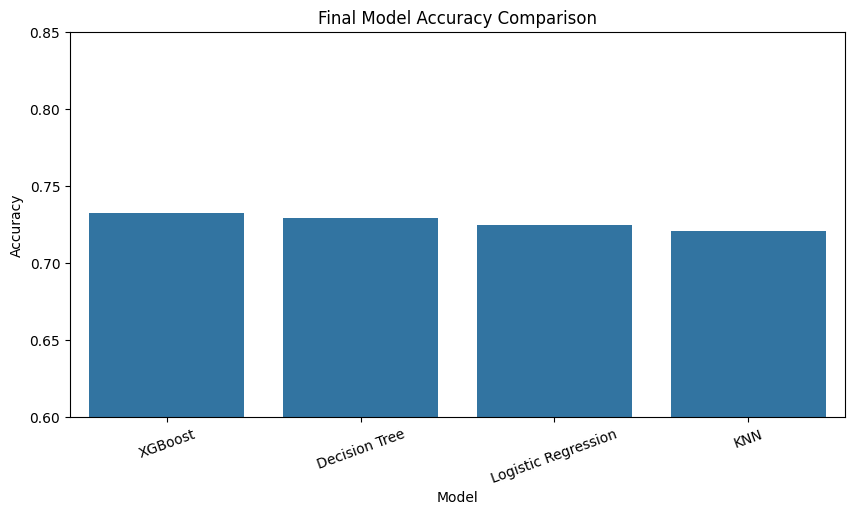

In [22]:
plt.figure(figsize=(10, 5))
sns.barplot(data=final_results, x="Model", y="Accuracy")
plt.title("Final Model Accuracy Comparison")
plt.ylim(0.60, max(0.85, final_results["Accuracy"].max() + 0.03))
plt.xticks(rotation=20)
plt.show()

## 10. Final Evaluation of the Best Model

In [23]:
best_model_name = final_results.loc[0, "Model"]
best_model = tuned_models[best_model_name]

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print("Best Model:", best_model_name)
print("Accuracy :", round(accuracy_score(y_test, y_pred) * 100, 2), "%")
print("Precision:", round(precision_score(y_test, y_pred) * 100, 2), "%")
print("Recall   :", round(recall_score(y_test, y_pred) * 100, 2), "%")
print("F1 Score :", round(f1_score(y_test, y_pred) * 100, 2), "%")
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob) * 100, 2), "%")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=["No Disease", "Disease"]))

Best Model: XGBoost
Accuracy : 73.26 %
Precision: 75.31 %
Recall   : 68.32 %
F1 Score : 71.65 %
ROC-AUC  : 79.91 %

Classification Report:

              precision    recall  f1-score   support

  No Disease       0.72      0.78      0.75      6938
     Disease       0.75      0.68      0.72      6787

    accuracy                           0.73     13725
   macro avg       0.73      0.73      0.73     13725
weighted avg       0.73      0.73      0.73     13725



### 10.1 Confusion Matrix

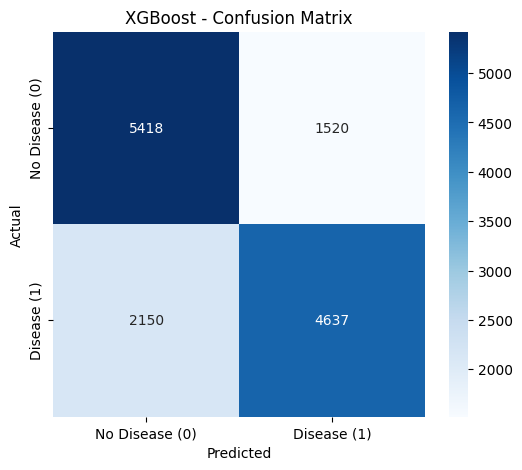

In [24]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["No Disease (0)", "Disease (1)"],
    yticklabels=["No Disease (0)", "Disease (1)"]
)
plt.title(f"{best_model_name} - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### 10.2 ROC Curve

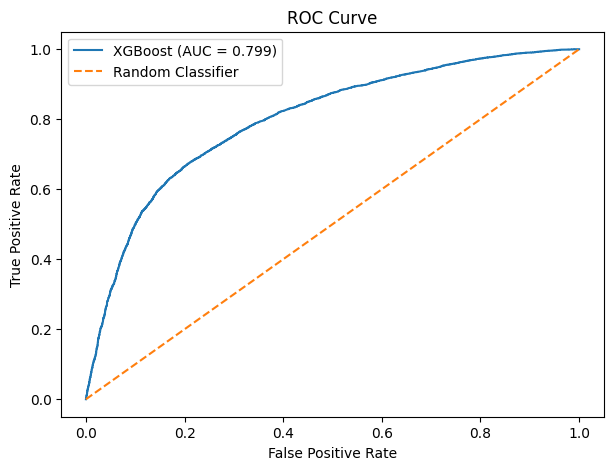

In [25]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"{best_model_name} (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], "--", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## 11. Feature Importance (when available)

In [26]:
if hasattr(best_model, "feature_importances_"):
    importance = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)
    display(importance.to_frame("Importance").head(15))

elif isinstance(best_model, Pipeline) and hasattr(best_model.named_steps["model"], "feature_importances_"):
    importance = pd.Series(
        best_model.named_steps["model"].feature_importances_,
        index=X.columns
    ).sort_values(ascending=False)
    display(importance.to_frame("Importance").head(15))
else:
    print("Feature importance is not directly available for the selected model.")

,Importance
ap_hi,0.595099
cholesterol,0.105787
MAP,0.101593
age,0.071880
active,0.024696
BMI,0.019023
gluc,0.015851
smoke,0.015737
alco,0.012132
weight,0.011416


In [27]:
!pip install gradio pandas numpy matplotlib

In [28]:
import gradio as gr


def predict_cardio_risk(age, gender, bp_sys, cholesterol, smoking, physical_activity):
    score = (age * 0.4) + (bp_sys * 0.3) + (cholesterol * 0.2)
    if smoking == "Yes":
        score += 15
    if physical_activity == "Low":
        score += 10

    if score < 70:
        risk_level = "Low Risk"
        recommendation = "Your health parameters are within normal ranges. Maintain a balanced diet and regular exercise."
        color = "#2e7d32"
    elif score < 100:
        risk_level = "Moderate Risk"
        recommendation = "Consider scheduling regular check-ups and monitoring your blood pressure and cholesterol levels."
        color = "#f57c00"
    else:
        risk_level = "High Risk"
        recommendation = "It is recommended to consult a medical specialist for further tests and evaluation."
        color = "#c62828"

    result_html = f"""
    <div style="text-align: center; padding: 20px; border-radius: 10px; background-color: #f8f9fa; border: 1px solid #e0e0e0;">
        <h2 style="color: {color}; margin-bottom: 10px;">Risk Level: {risk_level}</h2>
        <p style="font-size: 16px; color: #333;"><b>Recommendation:</b> {recommendation}</p>
    </div>
    """
    return result_html


with gr.Blocks(theme=gr.themes.Soft()) as app:
    gr.Markdown(
        """
        # Cardiovascular Risk AI Assessment Tool
        """
    )

    with gr.Row():
        with gr.Column(scale=1):
            gr.Markdown("### Input Parameters")
            age = gr.Number(label="Age", value=45)
            gender = gr.Radio(["Male", "Female"], label="Gender", value="Male")
            bp_sys = gr.Slider(
                80, 200, value=120, label="Systolic Blood Pressure (mmHg)"
            )
            cholesterol = gr.Slider(
                100, 400, value=190, label="Cholesterol (mg/dL)"
            )
            smoking = gr.Radio(["No", "Yes"], label="Smoking Status", value="No")
            activity = gr.Dropdown(
                ["High", "Moderate", "Low"],
                label="Physical Activity Level",
                value="Moderate",
            )

            submit_btn = gr.Button("Assess Risk", variant="primary")

        with gr.Column(scale=1):
            gr.Markdown("### Assessment Output")
            output_box = gr.HTML(
                value="<p style='text-align:center; color: #666;'>Enter parameters and click 'Assess Risk'.</p>"
            )

    submit_btn.click(
        fn=predict_cardio_risk,
        inputs=[age, gender, bp_sys, cholesterol, smoking, activity],
        outputs=output_box,
    )

app.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://da92fcdae08c6c49a3.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 12. Conclusion

The final model should be selected from the **test-set metrics produced above**, not from hardcoded values. Compare Accuracy, Precision, Recall, F1 Score, and ROC-AUC together, then report the best model and its actual parameters from `best_model`.